# Blobs multiclase gaussianos

Este notebook genera un dataset de tres clases con varias gaussianas por clase, y compara cómo clasifican distintos modelos de `scikit-learn`.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.mixture import GaussianMixture
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [12]:
rng = np.random.default_rng(13)

def sample_gaussian(center, cov, n):
    return rng.multivariate_normal(mean=center, cov=cov, size=n)

In [13]:
specs = {
    0: [
        ((4.0, 5.0), [[1.8, 0.2], [0.2, 1.8]], 700),
        ((15.5, 15.0), [[1.7, 0.3], [0.3, 1.9]], 650),
        ((24.0, 5.0), [[1.8, -0.2], [-0.2, 1.8]], 700),
        ((15.0, -4.8), [[1.6, 0.1], [0.1, 1.8]], 650),
    ],
    1: [
        ((4.0, -4.8), [[1.7, 0.0], [0.0, 2.0]], 900),
        ((10.0, 10.5), [[9.0, -6.5], [-6.5, 9.0]], 1200),
    ],
    2: [
        ((24.0, -4.8), [[1.9, 0.1], [0.1, 2.0]], 900),
        ((20.0, 10.0), [[8.5, 6.3], [6.3, 8.5]], 1200),
    ],
}

rows = []
for label, blobs in specs.items():
    for center, cov, n in blobs:
        points = sample_gaussian(center, cov, n)
        blob_df = pd.DataFrame(points, columns=["x1", "x2"])
        blob_df["label"] = label
        rows.append(blob_df)

df = pd.concat(rows, ignore_index=True)
X = df[["x1", "x2"]].to_numpy()
y = df["label"].to_numpy()
palette = {0: "#88bde6", 1: "#ef6a6a", 2: "#93d08a"}
df.head()

,x1,x2,label
0,4.926587,0.419900,0
1,2.979651,4.104221,0
2,2.336833,4.026667,0
3,2.144349,3.201134,0
4,3.997028,6.035431,0


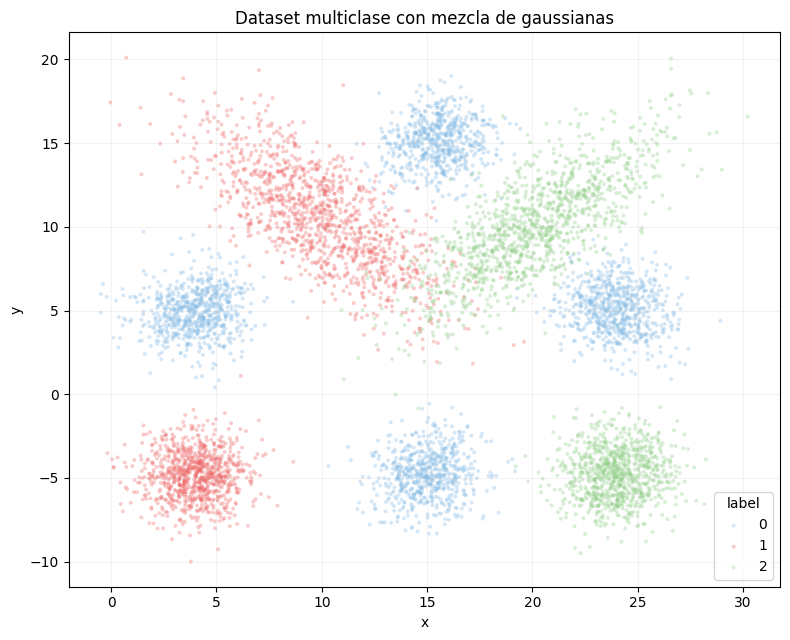

In [14]:
fig, ax = plt.subplots(figsize=(8, 6.5))
for label, color in palette.items():
    subset = df[df["label"] == label]
    ax.scatter(subset["x1"], subset["x2"], s=8, c=color, alpha=0.35, edgecolors="none", label=label)
ax.set_title("Dataset multiclase con mezcla de gaussianas")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(title="label")
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

In [15]:
class GMMBayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=2, covariance_type="full", reg_covar=1e-4, random_state=10):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.reg_covar = reg_covar
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_ = np.array([(y == cls).mean() for cls in self.classes_])
        self.models_ = {}
        for cls in self.classes_:
            gmm = GaussianMixture(n_components=self.n_components, covariance_type=self.covariance_type, reg_covar=self.reg_covar, random_state=self.random_state + int(cls))
            gmm.fit(X[y == cls])
            self.models_[cls] = gmm
        return self

    def predict_log_proba(self, X):
        log_posts = []
        for i, cls in enumerate(self.classes_):
            log_density = self.models_[cls].score_samples(X)
            log_posts.append(np.log(self.priors_[i]) + log_density)
        log_posts = np.column_stack(log_posts)
        normalizer = np.logaddexp.reduce(log_posts, axis=1, keepdims=True)
        return log_posts - normalizer

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_log_proba(X), axis=1)]

In [16]:
models = {
    "Naive Bayes": GaussianNB(var_smoothing=1e-4),
    "KNN (k=9)": KNeighborsClassifier(n_neighbors=9),
    "Solo priors": DummyClassifier(strategy="prior"),
    "1 gaussiana / clase": QuadraticDiscriminantAnalysis(reg_param=1e-3, store_covariance=True),
    "Mezcla de gaussianas": GMMBayesClassifier(n_components=2, reg_covar=1e-4, random_state=10),
}

for model in models.values():
    model.fit(X, y)

metrics_df = pd.DataFrame([
    {"modelo": name, "accuracy_entrenamiento": accuracy_score(y, model.predict(X))}
    for name, model in models.items()
]).sort_values("accuracy_entrenamiento", ascending=False).reset_index(drop=True)

metrics_df

,modelo,accuracy_entrenamiento
0,KNN (k=9),0.981159
1,Mezcla de gaussianas,0.961739
2,Naive Bayes,0.675507
3,1 gaussiana / clase,0.672174
4,Solo priors,0.391304


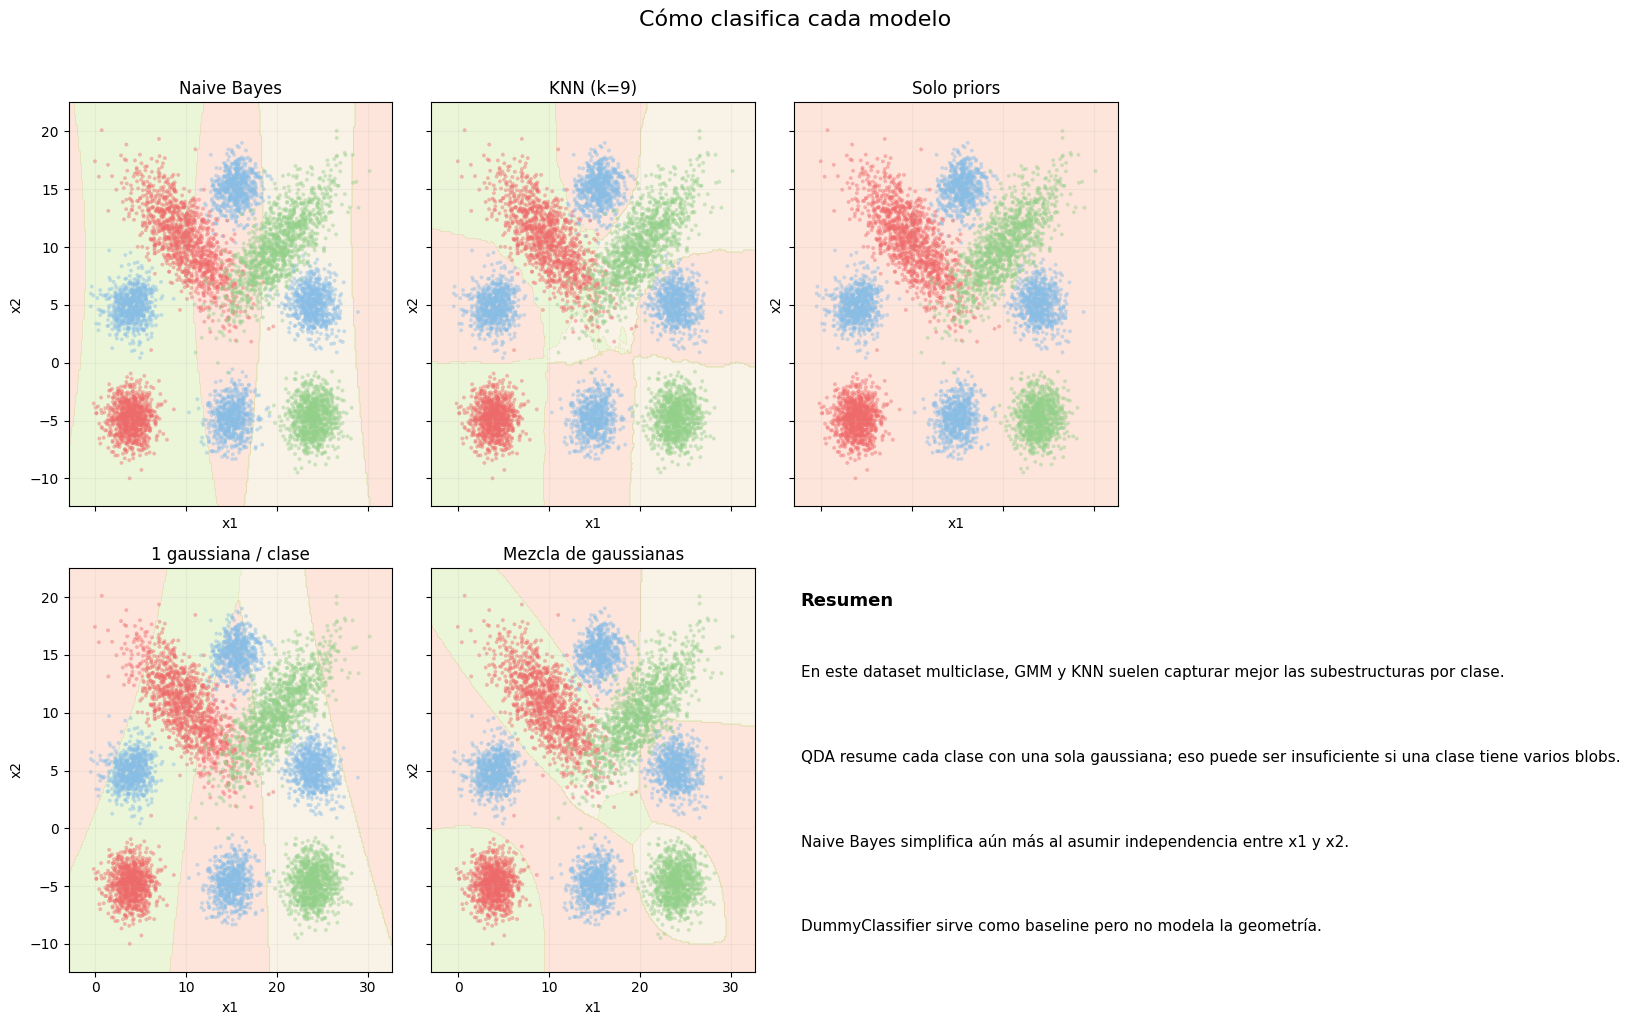

In [17]:
def make_grid(X, steps=240, padding=0.08):
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()
    dx = (x_max - x_min) * padding
    dy = (y_max - y_min) * padding
    xx, yy = np.meshgrid(np.linspace(x_min - dx, x_max + dx, steps), np.linspace(y_min - dy, y_max + dy, steps))
    return xx, yy, np.column_stack([xx.ravel(), yy.ravel()])

def plot_regions(ax, model, name, X, y, xx, yy, grid, palette):
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.arange(len(np.unique(y)) + 1) - 0.5, cmap=plt.cm.Set2, alpha=0.22)
    for cls, color in palette.items():
        subset = X[y == cls]
        ax.scatter(subset[:, 0], subset[:, 1], s=8, c=color, alpha=0.45, edgecolors="none")
    ax.set_title(name)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.grid(True, alpha=0.15)

xx, yy, grid = make_grid(X)
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    plot_regions(ax, model, name, X, y, xx, yy, grid, palette)

axes[-1].axis("off")
axes[-1].text(0.02, 0.94, "Resumen", transform=axes[-1].transAxes, fontsize=13, fontweight="bold", va="top")
axes[-1].text(0.02, 0.73, "En este dataset multiclase, GMM y KNN suelen capturar mejor las subestructuras por clase.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.52, "QDA resume cada clase con una sola gaussiana; eso puede ser insuficiente si una clase tiene varios blobs.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.31, "Naive Bayes simplifica aún más al asumir independencia entre x1 y x2.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.10, "DummyClassifier sirve como baseline pero no modela la geometría.", transform=axes[-1].transAxes, fontsize=11)

fig.suptitle("Cómo clasifica cada modelo", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
df.to_csv("blobs_multiclase.csv", index=False)
print("Archivo guardado como blobs_multiclase.csv")

Archivo guardado como blobs_multiclase.csv
